In [2]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_e59b447ec3e8c16c2c33682236cfd6fe"

In [2]:
import kagglehub

path = kagglehub.competition_download("home-credit-default-risk")
print(path)

C:\Users\DESK0059-\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\DESK0059-\.cache\kagglehub\competitions\home-credit-default-risk


In [3]:
import os
print(os.listdir(path))

['application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv']


### Item 1: Understand what each table and row represents

In [4]:
import pandas as pd 

app_train = pd.read_csv(os.path.join(path, "application_train.csv"))
print(app_train.shape)
app_train.head()
app_train.columns.value_counts()

(307511, 122)


SK_ID_CURR                    1
TARGET                        1
NAME_CONTRACT_TYPE            1
CODE_GENDER                   1
FLAG_OWN_CAR                  1
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     1
AMT_REQ_CREDIT_BUREAU_WEEK    1
AMT_REQ_CREDIT_BUREAU_MON     1
AMT_REQ_CREDIT_BUREAU_QRT     1
AMT_REQ_CREDIT_BUREAU_YEAR    1
Name: count, Length: 122, dtype: int64

### Item 2 — How the Tables Connect

- `SK_ID_CURR` = the main key, identifies one loan application (present in almost every table)
- `application_train` (SK_ID_CURR) is the central table — everything else links back to it
- `bureau` connects via `SK_ID_CURR` → one applicant can have multiple past credits (with other banks)
- `bureau_balance` connects one level deeper via `SK_ID_BUREAU` → monthly status of each bureau credit
- `previous_application` connects via `SK_ID_CURR` → one applicant can have multiple past Home Credit loans, each with its own `SK_ID_PREV`
- `POS_CASH_balance`, `credit_card_balance`, `installments_payments` connect via `SK_ID_PREV` → monthly/payment-level history for each previous loan

**Relationship type:** one-to-many at every level (one applicant → many bureau credits → many monthly records)

**For Day 3:** only using `application_train.csv` — other tables noted here for future feature engineering, not joined yet.

### Item 3: Check Shapes, Columns, and Data Types

In [5]:
app_train.info()
app_train.isnull().sum().sort_values(ascending=False).head(15)
app_train.head()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Item 4: Classify Your Columns

In [6]:
# Numerical columns
numerical_cols = app_train.select_dtypes(include=['int64','float64']).columns.tolist()

# Categorical (object/string) columns
categorical_cols = app_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))
print(categorical_cols)  # let's eyeball what these are

Numerical columns: 106
Categorical columns: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


C:\Users\DESK0059-\AppData\Local\Temp\ipykernel_15764\2403538237.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = app_train.select_dtypes(include=['object']).columns.tolist()


### Item 5 — Missing Values

In [7]:
missing = app_train.isnull().sum()
missing_pct = (missing / len(app_train)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_df.head(20)

,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [8]:
app_train['COMMONAREA_AVG_missing'] = app_train['COMMONAREA_AVG'].isnull()
contingency = pd.crosstab(app_train['NAME_HOUSING_TYPE'], app_train['COMMONAREA_AVG_missing'])
print(contingency)

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency)
print("Chi2:", chi2, "p-value:", p)

C:\Users\DESK0059-\AppData\Local\Temp\ipykernel_15764\4196415565.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train['COMMONAREA_AVG_missing'] = app_train['COMMONAREA_AVG'].isnull()


COMMONAREA_AVG_missing  False   True 
NAME_HOUSING_TYPE                    
Co-op apartment           359     763
House / apartment       82376  190492
Municipal apartment      4262    6921
Office apartment          750    1867
Rented apartment          949    3932
With parents             3950   10890
Chi2: 695.230491505251 p-value: 5.278392086200827e-148


### Item 6 — Duplicates
Goal: make sure each row/applicant is unique — duplicates would silently bias the model.

In [9]:
print("Exact duplicate rows:", app_train.duplicated().sum())
print("Duplicate SK_ID_CURR:", app_train['SK_ID_CURR'].duplicated().sum())

Exact duplicate rows: 0
Duplicate SK_ID_CURR: 0


### Item 7 — Target Distribution


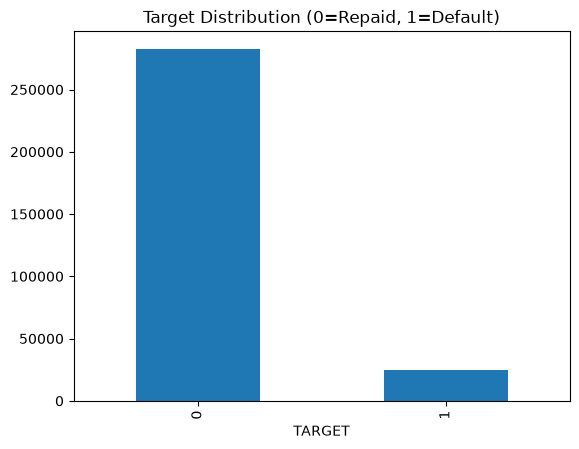

In [12]:
import matplotlib.pyplot as plt
app_train['TARGET'].value_counts()
app_train['TARGET'].value_counts(normalize=True) * 100
app_train['TARGET'].value_counts().plot(kind='bar')
plt.title('Target Distribution (0=Repaid, 1=Default)')
plt.show()

### Item 8 — Numerical Distributions
Goal: understand the shape (skew, spread) of key numeric features — flags need for transforms later.

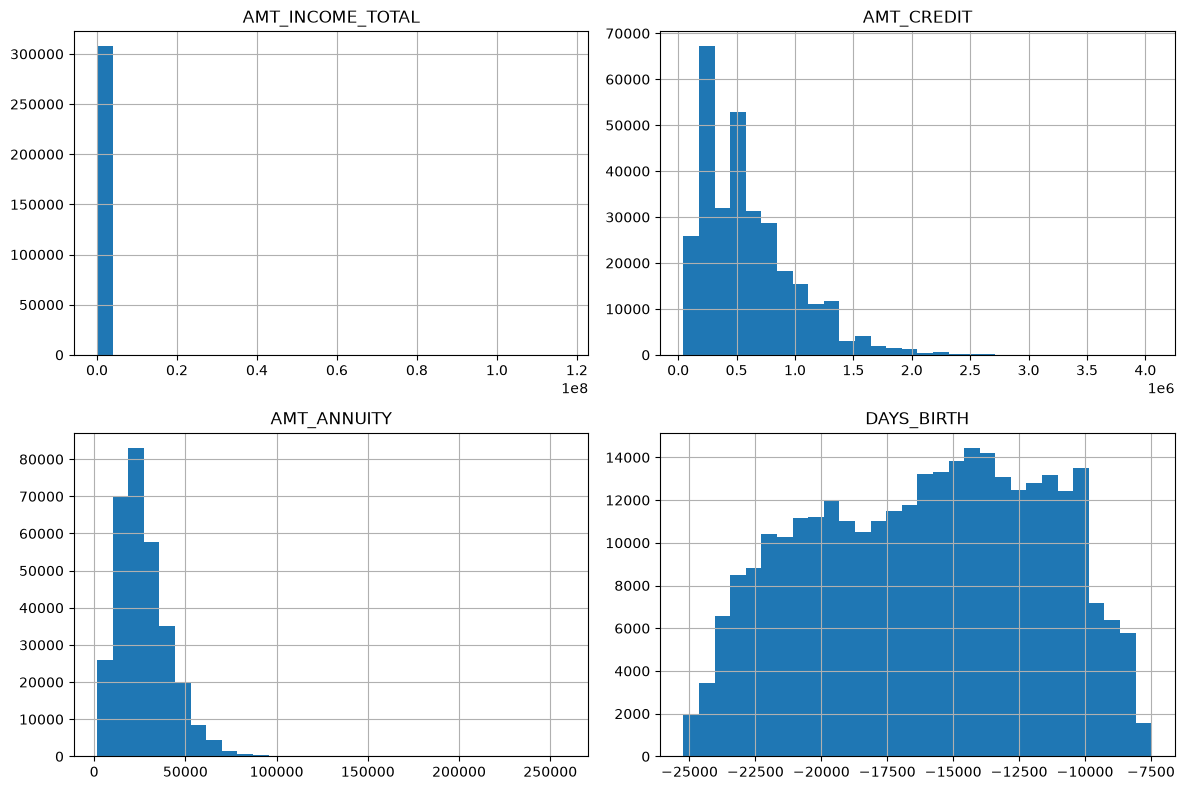

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH
count,3.075110e+05,3.075110e+05,307499.000000,307511.000000
mean,1.687979e+05,5.990260e+05,27108.573909,-16036.995067
std,2.371231e+05,4.024908e+05,14493.737315,4363.988632
min,2.565000e+04,4.500000e+04,1615.500000,-25229.000000
25%,1.125000e+05,2.700000e+05,16524.000000,-19682.000000
50%,1.471500e+05,5.135310e+05,24903.000000,-15750.000000
75%,2.025000e+05,8.086500e+05,34596.000000,-12413.000000
max,1.170000e+08,4.050000e+06,258025.500000,-7489.000000


In [13]:
num_cols_sample = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH']
app_train[num_cols_sample].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

app_train[num_cols_sample].describe()

### Item 9 — Categorical Distributions
Goal: check category frequencies — rare categories (e.g. <1%) may need grouping before modeling.

In [14]:
for col in categorical_cols[:5]:
    print(app_train[col].value_counts(normalize=True) * 100)
    print("---")

NAME_CONTRACT_TYPE
Cash loans         90.478715
Revolving loans     9.521285
Name: proportion, dtype: float64
---
CODE_GENDER
F      65.834393
M      34.164306
XNA     0.001301
Name: proportion, dtype: float64
---
FLAG_OWN_CAR
N    65.989184
Y    34.010816
Name: proportion, dtype: float64
---
FLAG_OWN_REALTY
Y    69.367275
N    30.632725
Name: proportion, dtype: float64
---
NAME_TYPE_SUITE
Unaccompanied      81.159562
Family             13.111205
Spouse, partner     3.713029
Children            1.066884
Other_B             0.578018
Other_A             0.282804
Group of people     0.088499
Name: proportion, dtype: float64
---


### Item 10 — Outlier Detection
Goal: flag extreme values statistically (IQR) and by distance from mean (Z-score), and see them visually.

IQR outliers: 14035
Z-score outliers: 454


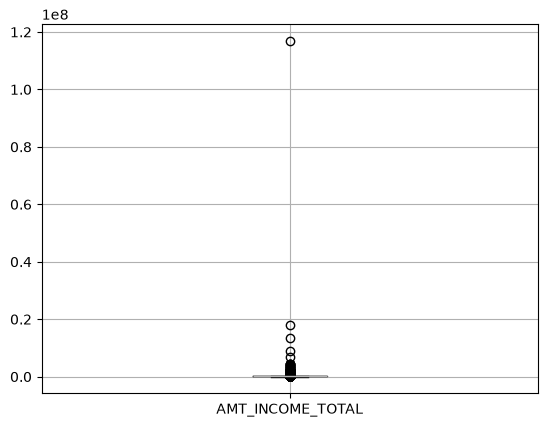

In [15]:
import numpy as np

col = 'AMT_INCOME_TOTAL'
Q1 = app_train[col].quantile(0.25)
Q3 = app_train[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers_iqr = app_train[(app_train[col] < lower) | (app_train[col] > upper)]
print("IQR outliers:", outliers_iqr.shape[0])

z_scores = (app_train[col] - app_train[col].mean()) / app_train[col].std()
outliers_z = app_train[abs(z_scores) > 3]
print("Z-score outliers:", outliers_z.shape[0])

app_train.boxplot(column=col)
plt.show()

### Item 11 — Outlier Decision
Goal: decide, per flagged column, whether to remove/cap/transform/keep — write reasoning, no code.

### Item 12 — Feature Relationships
Goal: see which numeric features move with TARGET (correlation), and how default rate varies across a category — early signal for feature importance.

In [17]:
corr = app_train[numerical_cols].corr()['TARGET'].sort_values(ascending=False)
print(corr.head(10))
print(corr.tail(10))

app_train.groupby('NAME_HOUSING_TYPE')['TARGET'].mean().sort_values(ascending=False)

TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
FLOORSMAX_MODE               -0.043226
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_AVG                -0.044003
DAYS_EMPLOYED                -0.044932
EXT_SOURCE_1                 -0.155317
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64


NAME_HOUSING_TYPE
Rented apartment       0.123131
With parents           0.116981
Municipal apartment    0.085397
Co-op apartment        0.079323
House / apartment      0.077957
Office apartment       0.065724
Name: TARGET, dtype: float64

### Item 13 — Validity Checks
Goal: catch broken/impossible values (e.g. DAYS_EMPLOYED has a known fake placeholder in this dataset) before they distort analysis.

In [18]:
print(app_train['DAYS_EMPLOYED'].describe())
print(app_train['CODE_GENDER'].value_counts())
print(app_train['DAYS_BIRTH'].max(), app_train['DAYS_BIRTH'].min())

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
-7489 -25229


### Item 14 — Target Leakage Check
Goal: spot any column that would only be known AFTER the loan outcome — including it would make the model cheat. Scan column list, note candidates, no code.

### Item 15 — Data-Quality Risk List
Goal: rank everything wrong you found (Items 5–14) from worst to least severe — this becomes your "risks" writeup.

### Item 16 — Top 10 Predictive Features
Goal: shortlist the numeric features most correlated with TARGET, as an early (rough) predictive signal.

In [19]:
corr_abs = app_train[numerical_cols].corr()['TARGET'].abs().sort_values(ascending=False)
corr_abs.head(11)

TARGET                         1.000000
EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
Name: TARGET, dtype: float64

### Item 17 — Target Definition

TARGET = 1 means the applicant had significant payment difficulty on their loan — specifically, they were late paying installments by more than X days (Home Credit's internal definition, commonly 90+ days past due) at some point during the loan. TARGET = 0 means the loan was repaid without major delinquency.

In plain business terms: "Will this applicant struggle to repay, badly enough that the bank flags it as a problem loan?" It's not "did they miss one payment" — it's a serious default marker, not minor lateness.

### Item 18 — Client Questions

What exact threshold defines "default" here?Is it 30/60/90+ days late, or missed final repayment? This changes what we're actually predicting.
Do you want to predict default at application time (before any loan history exists), or can we use behavior after the loan starts? — This determines which features are even legal to use (avoids leakage).
What's the business cost of a false positive vs false negative? — Rejecting a good customer (lost revenue) vs approving a bad one (lost principal) aren't equal — this drives the metric we optimize (precision vs recall vs a custom cost function).
(bonus) Is this model meant to replace or assist the existing approval process? — Changes how much interpretability/explainability is required.